<a href="https://colab.research.google.com/github/rohanjadav240/Java_Journal/blob/main/DL_J1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Description: Student Performance Analysis and Prediction

This project focuses on analyzing student performance data and developing a machine learning model to predict student outcomes (Pass/Fail). The workflow encompasses several key stages:

1.  **Data Loading and Initial Exploration**: The project began by loading a dataset containing student information such as `Student_ID`, `Name`, `Attendance`, `Internal_Marks`, `Assignment_Marks`, `Study_Hours`, `Practical_Marks`, `GPA`, and `Result`. Initial steps included displaying the first few records and examining the dataset's shape and column names.

2.  **Data Cleaning and Preprocessing**: A comprehensive data cleaning process was performed to ensure data quality and integrity. This involved:
    *   Converting several columns (`Attendance`, `Internal_Marks`, `Study_Hours`) to appropriate numerical data types and handling missing values by imputing with the median.
    *   Identifying and removing duplicate records.
    *   Correcting invalid `Attendance` and `GPA` values that fell outside their respective valid ranges (0-100 for attendance, 0-10 for GPA).
    *   Standardizing the `Result` column to consistent 'PASS'/'FAIL' values.

3.  **Exploratory Data Analysis (EDA)**: EDA was conducted to understand the dataset's characteristics and uncover insights into student performance. Key analyses included:
    *   Determining the number of students who passed and failed.
    *   Visualizing the distributions of `Result`, `Attendance`, and `GPA` using bar charts and histograms.
    *   Calculating descriptive statistics (min, max, mean, median) for `Attendance` and `GPA`.
    *   Visualizing relationships between `Attendance`, `Internal_Marks`, `Study_Hours`, `GPA`, and the `Result` using boxplots.
    *   Generating and visualizing a correlation matrix to understand the relationships between numerical attributes, identifying 'Internal_Marks' as having the highest impact on GPA.
    *   Detecting outliers in numerical features using boxplots.

4.  **Feature Selection and Data Preparation**: For model development:
    *   Relevant features (`Attendance`, `Internal_Marks`, `Assignment_Marks`, `Study_Hours`, `Practical_Marks`, `GPA`) were selected as independent variables (X).
    *   The `Result` column was chosen as the dependent variable (Y) and converted into a numerical format (0 for 'FAIL', 1 for 'PASS') using `LabelEncoder`.
    *   The dataset was split into training (80%) and testing (20%) sets to facilitate model training and evaluation.

5.  **Model Development and Evaluation**: A Logistic Regression model was built and trained on the prepared data. The model's performance was then evaluated using standard metrics:
    *   **Accuracy**: The model achieved a high accuracy of 97.93%, indicating its strong predictive capability.
    *   **Confusion Matrix**: A confusion matrix was generated to detail true positives, true negatives, false positives, and false negatives.
    *   **Classification Report**: Precision, Recall, and F1-score were calculated for both 'PASS' and 'FAIL' classes, further confirming the model's satisfactory performance across different metrics.

##**Section A: Dataset Understanding**

---

**1] Load Libraries And Student Performance dataset and display the first 10 records.**

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [238]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Sem-5/DL/Journal/J1/student_performance.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [239]:
df.head(10)

,Student_ID,Name,Attendance,Internal_Marks,Assignment_Marks,Study_Hours,Practical_Marks,GPA,Result
0,1000,Sneha,49.0,8.0,13.0,2.0,9.0,4.8,Fail
1,1001,Pooja,46.0,26.0,18.0,1.0,6.0,4.5,Pass
2,1002,Krunal,38.0,25.0,11.0,6.0,16.0,7.9,Pass
3,1003,Khushi,63.0,22.0,13.0,1.0,18.0,8.4,Pass
4,1004,Riya,89.0,18.0,13.0,2.0,9.0,9.3,Pass
5,1005,Parth,48.0,10.0,17.0,1.0,11.0,8.7,Pass
6,1006,Het,68.0,9.0,19.0,5.0,7.0,9.4,Pass
7,1007,Jay,45.0,25.0,14.0,6.0,15.0,8.9,Pass
8,1008,Tina,59.0,30.0,7.0,1.0,16.0,5.3,Pass
9,1009,Yash,45.0,15.0,8.0,4.0,10.0,6.5,Fail


**2] Determine the total number of rows and columns in the dataset.**

In [240]:
print('Total number of rows : ',df.shape[0])
print('Total numbers of columns : ',df.shape[1])

Total number of rows :  8150
Total numbers of columns :  9


**3] Display the names of all attributes (columns) present in the dataset.**

In [241]:
print('Columns Name : ',df.columns.to_list())

Columns Name :  ['Student_ID', 'Name', 'Attendance', 'Internal_Marks', 'Assignment_Marks', 'Study_Hours', 'Practical_Marks', 'GPA', 'Result']


In [242]:
df.dtypes

,0
Student_ID,int64
Name,object
Attendance,object
Internal_Marks,object
Assignment_Marks,float64
Study_Hours,object
Practical_Marks,float64
GPA,float64
Result,object


In [243]:
df['Attendance'] = pd.to_numeric(df['Attendance'], errors='coerce')
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].median())
df['Attendance'] = df['Attendance'].astype(int)

df['Internal_Marks'] = pd.to_numeric(df['Internal_Marks'], errors='coerce')
df['Internal_Marks'] = df['Internal_Marks'].fillna(df['Internal_Marks'].median())
df['Internal_Marks'] = df['Internal_Marks'].astype(float)

df['Assignment_Marks'] = pd.to_numeric(df['Assignment_Marks'], errors='coerce')
df['Assignment_Marks'] = df['Assignment_Marks'].fillna(df['Assignment_Marks'].median())
df['Assignment_Marks'] = df['Assignment_Marks'].astype(float)

df['Study_Hours'] = pd.to_numeric(df['Study_Hours'], errors='coerce')
df['Study_Hours'] = df['Study_Hours'].fillna(df['Study_Hours'].median())
df['Study_Hours'] = df['Study_Hours'].astype(float)
df.dtypes

,0
Student_ID,int64
Name,object
Attendance,int64
Internal_Marks,float64
Assignment_Marks,float64
Study_Hours,float64
Practical_Marks,float64
GPA,float64
Result,object


**5] Identify the target variable used for prediction.**

In [244]:
print('The target variable is Result (or alternatively GPA, depending on your specific assignment goals, but typically Result is the final outcome here).')

The target variable is Result (or alternatively GPA, depending on your specific assignment goals, but typically Result is the final outcome here).


**6] Determine whether the problem is Classification or Regression. Justify your
answer.**

In [245]:
print('Problem Type: Classification (if predicting Result) or Regression (if predicting GPA).')

Problem Type: Classification (if predicting Result) or Regression (if predicting GPA).


##**Section B: Data Cleaning**

---



**7] Find the total number of missing values present in each attribute.**

In [246]:
df.isnull().sum()

,0
Student_ID,0
Name,0
Attendance,0
Internal_Marks,0
Assignment_Marks,0
Study_Hours,0
Practical_Marks,124
GPA,120
Result,0


**8] Handle all missing values using an appropriate technique.**

In [247]:
for col in df.columns:
    if df[col].dtypes=='object':
        df[col]=df[col].fillna(df[col].mode()[0])
    else:
        df[col]=df[col].fillna(df[col].median())

**9] Identify duplicate records in the dataset.**

In [248]:
print('Duplicated Records : ',df.duplicated().sum())

Duplicated Records :  145


**10] Remove duplicate records from the dataset.**

In [249]:
df.drop_duplicates(inplace=True)
print('Duplicated Records : ',df.duplicated().sum())

Duplicated Records :  0


**11] Find attendance values that are outside the valid range (0–100).**

In [250]:
invalid_attendance=df[(df['Attendance']<0) | (df['Attendance']>100)]
invalid_attendance.head()

,Student_ID,Name,Attendance,Internal_Marks,Assignment_Marks,Study_Hours,Practical_Marks,GPA,Result
64,1064,Het,-5,17.0,12.0,2.0,6.0,7.6,Fail
571,1571,Jay,300,11.0,8.0,3.0,19.0,6.9,Fail
657,1657,Jinal,-5,30.0,15.0,6.0,17.0,9.1,Pass
671,1671,Karan,-5,26.0,13.0,1.0,11.0,6.6,Pass
926,1926,Vishal,110,14.0,7.0,3.0,14.0,4.1,Fail


**12] Correct or remove invalid attendance values.**

In [251]:
df=df[(df['Attendance']>=0) & (df['Attendance']<=100)]

**13] Identify GPA values outside the valid range (0–10).**

In [252]:
invalid_GPA=df[(df['GPA']<0) | (df['GPA']>10)]
invalid_GPA.head()

,Student_ID,Name,Attendance,Internal_Marks,Assignment_Marks,Study_Hours,Practical_Marks,GPA,Result
67,1067,Krunal,39,11.0,18.0,3.0,17.0,15.0,Pass
152,1152,Mansi,83,20.0,9.0,4.0,6.0,15.0,Pass
195,1195,Mehul,44,10.0,15.0,5.0,8.0,15.0,Fail
1090,2090,Ravi,66,8.0,8.0,3.0,13.0,15.0,Fail
1511,2511,Deep,36,11.0,8.0,1.0,7.0,15.0,Fail


**14] Correct or remove invalid GPA values.**

In [253]:
df=df[(df['GPA']>=0) & (df['GPA']<=10)]

**15] Standardize the values of the Result column (Pass, PASS, pass, Fail, fail).**

In [254]:
df['Result']=df['Result'].str.upper()

**18] Generate a cleaned version of the dataset.**

In [255]:
df.to_csv('cleaned_student_performance.csv',index=False)

##**Section C: Exploratory Data Analysis (EDA)**

---



**19] Find the number of students who passed and failed.**

In [256]:
df['Result'].value_counts()

,count
Result,
PASS,6493
FAIL,1458


**20] Visualize the class distribution using a bar chart.**

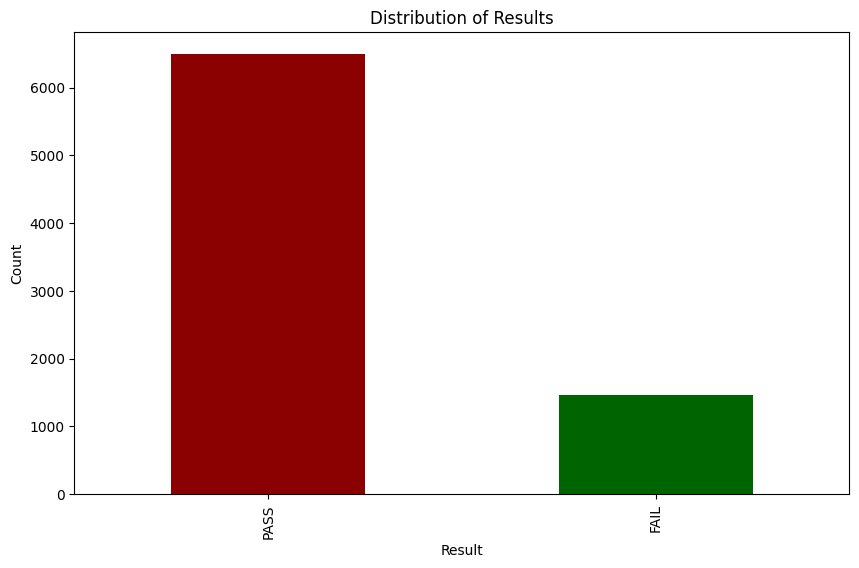

In [257]:
plt.figure(figsize=(10,6))
df['Result'].value_counts().plot(kind='bar',color=['darkred','darkgreen'])
plt.title('Distribution of Results')
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()

**21] Analyze the distribution of Attendance using a histogram.**

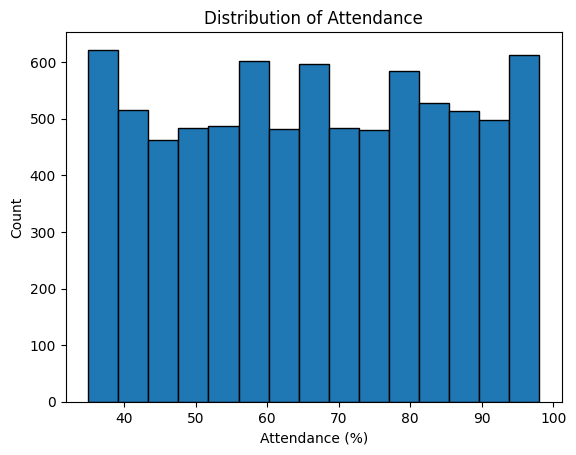

In [258]:
plt.hist(df['Attendance'], bins=15, edgecolor='black')
plt.title('Distribution of Attendance')
plt.xlabel('Attendance (%)')
plt.ylabel('Count')
plt.show()

**22] Analyze the distribution of GPA using a histogram.**

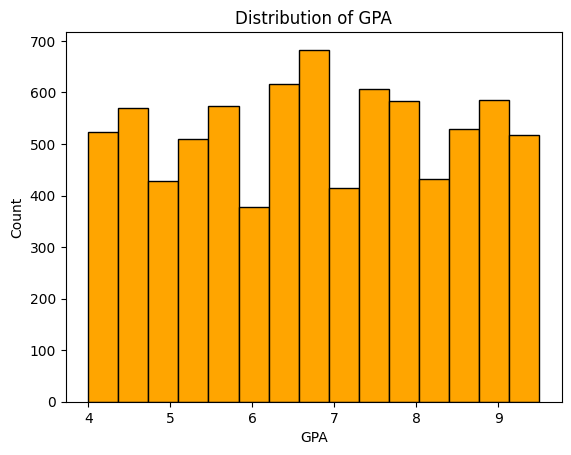

In [259]:
plt.hist(df['GPA'], bins=15, color='orange', edgecolor='black')
plt.title('Distribution of GPA')
plt.xlabel('GPA')
plt.ylabel('Count')
plt.show()

**23] Identify the minimum, maximum, mean, and median Attendance.**

In [260]:
attendance_stats = df['Attendance'].agg(['min', 'max', 'mean', 'median'])
print(attendance_stats)

min       35.000000
max       98.000000
mean      66.617029
median    67.000000
Name: Attendance, dtype: float64


**24] Identify the minimum, maximum, mean, and median GPA.**

In [261]:
gpa_stats = df['GPA'].agg(['min', 'max', 'mean', 'median'])
print(gpa_stats)

min       4.000000
max       9.500000
mean      6.763376
median    6.800000
Name: GPA, dtype: float64


**25] Visualize the relationship between Attendance and Result.**

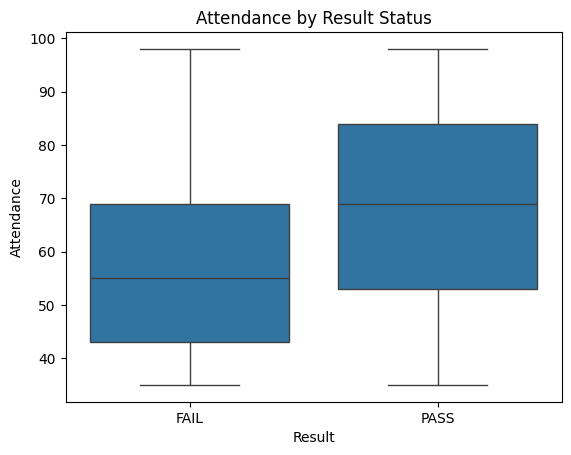

In [262]:
sns.boxplot(x='Result', y='Attendance', data=df)
plt.title('Attendance by Result Status')
plt.show()

**26] Visualize the relationship between Internal Marks and Result.**

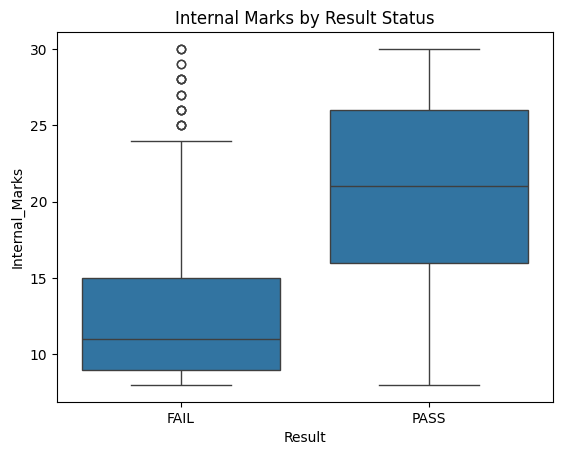

In [263]:
sns.boxplot(x='Result', y='Internal_Marks', data=df)
plt.title('Internal Marks by Result Status')
plt.show()

**27] Visualize the relationship between Study Hours and Result.**

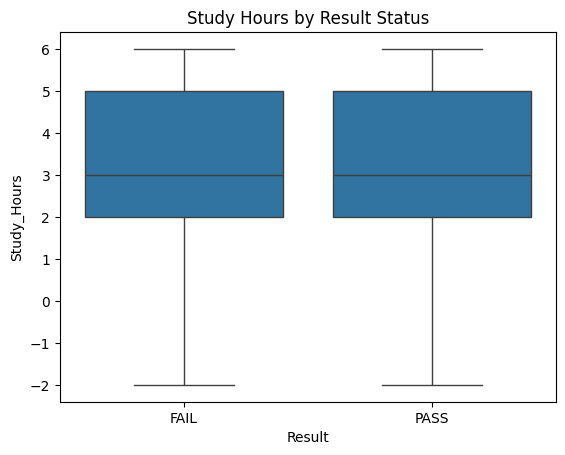

In [264]:
sns.boxplot(x='Result', y='Study_Hours', data=df)
plt.title('Study Hours by Result Status')
plt.show()

**28] Visualize the relationship between GPA and Result.**

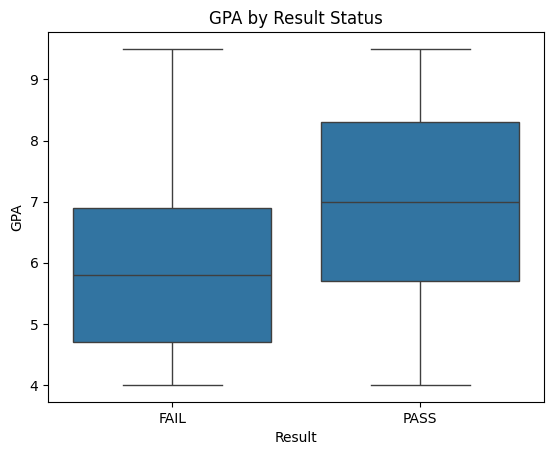

In [265]:
sns.boxplot(x='Result', y='GPA', data=df)
plt.title('GPA by Result Status')
plt.show()

**29] Generate the correlation matrix of all numerical attributes.**

In [266]:
numerical_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Student_ID'])
corr_matrix = numerical_df.corr()
display(corr_matrix)

,Attendance,Internal_Marks,Assignment_Marks,Study_Hours,Practical_Marks,GPA
Attendance,1.000000,-0.007574,0.004254,0.010044,0.004887,0.015170
Internal_Marks,-0.007574,1.000000,0.013512,-0.012567,0.016560,0.023247
Assignment_Marks,0.004254,0.013512,1.000000,0.007759,0.003801,-0.005959
Study_Hours,0.010044,-0.012567,0.007759,1.000000,0.015583,-0.005178
Practical_Marks,0.004887,0.016560,0.003801,0.015583,1.000000,0.004367
GPA,0.015170,0.023247,-0.005959,-0.005178,0.004367,1.000000


**30] Visualize the correlation matrix using a heatmap.**

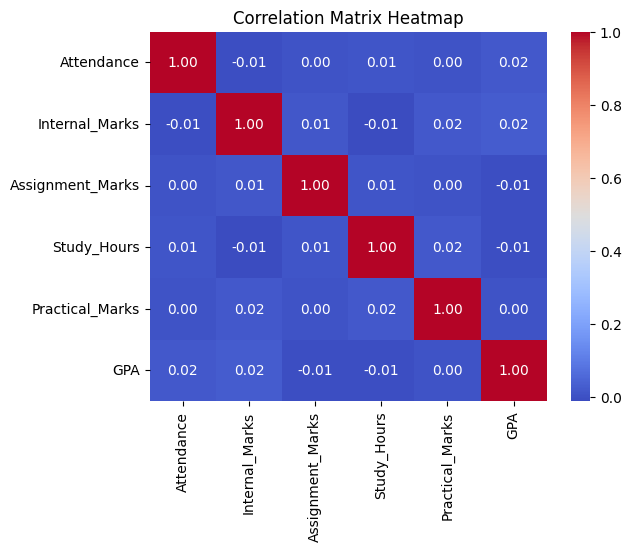

In [267]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

**31] Identify the attribute most strongly related to student performance.**

In [268]:
# Sorting correlation values relative to GPA to find the strongest relationship
strongest_relation = corr_matrix['GPA'].sort_values(ascending=False)
print("Attributes correlated with GPA:\n", strongest_relation)

Attributes correlated with GPA:
 GPA                 1.000000
Internal_Marks      0.023247
Attendance          0.015170
Practical_Marks     0.004367
Study_Hours        -0.005178
Assignment_Marks   -0.005959
Name: GPA, dtype: float64


**32] Identify any outliers present in the dataset using boxplots.**

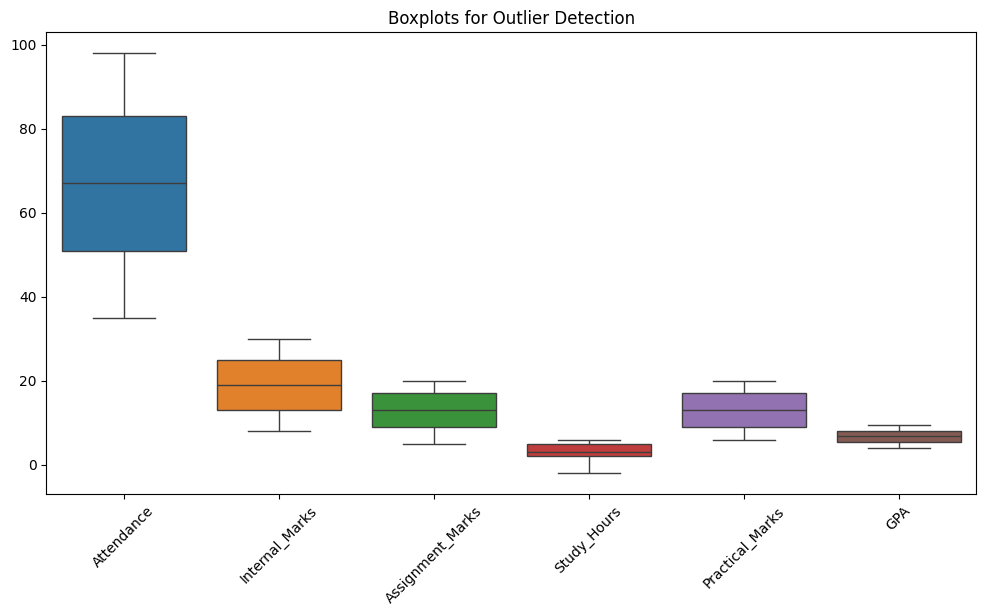

In [269]:
# Plot all key numerical attributes to visually spot outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=numerical_df)
plt.xticks(rotation=45)
plt.title('Boxplots for Outlier Detection')
plt.show()

##**Section D: Feature Selection and Data Preparation**

---



**33] Select appropriate features for student result prediction.**

In [270]:
features = ["Attendance", "Internal_Marks", "Assignment_Marks", "Study_Hours", "Practical_Marks", "GPA"]

**34] Separate the independent variables (X) and dependent variable (Y).**

In [271]:
X = df[features]
Y = df["Result"]

**35] Convert the Result attribute into numerical form.**

In [272]:
# LabelEncoder encodes alphabetically: "Fail" becomes 0, "Pass" becomes 1
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(Y)

**36] Split the dataset into training and testing sets using an 80:20 ratio.**

In [273]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_encoded, test_size=0.20, random_state=42)

##**Section E: Model Development**

---



**37. Build a Logistic Regression model for student result prediction.**

In [274]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

**38] Train the model using the training dataset.**

In [275]:
model.fit(X_train, Y_train)

LogisticRegression()

**39] Predict student results using the testing dataset.**

In [276]:
Y_pred = model.predict(X_test)

**40] Display the predicted results.**

In [277]:
print("Predicted binary array:", Y_pred)
# Optional: Inverse transform to show original labels ("Pass"/"Fail")
print("Predicted text labels:", encoder.inverse_transform(Y_pred))

Predicted binary array: [1 0 1 ... 1 1 1]
Predicted text labels: ['PASS' 'FAIL' 'PASS' ... 'PASS' 'PASS' 'PASS']


##**Section F: Model Evaluation**

---



**41] Calculate the accuracy of the developed model.**

In [278]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 97.93%


**42] Generate the confusion matrix for the model.**

In [279]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix")
print(cm)

Confusion Matrix
[[ 285   22]
 [  11 1273]]


**43] Calculate Precision, Recall, and F1-Score.**

In [280]:
# Passing the encoder classes directly preserves proper label alignment
from sklearn.metrics import classification_report
report = classification_report(Y_test, Y_pred, target_names=encoder.classes_, zero_division=0)
print("\t\tClassification Report\n")
print(report)

		Classification Report

              precision    recall  f1-score   support

        FAIL       0.96      0.93      0.95       307
        PASS       0.98      0.99      0.99      1284

    accuracy                           0.98      1591
   macro avg       0.97      0.96      0.97      1591
weighted avg       0.98      0.98      0.98      1591



**44] Interpret the obtained accuracy.**

The model achieved an accuracy of 97.93%. This means that the model correctly predicted the student's result (Pass/Fail) approximately 98% of the time on the test dataset.

**45. Identify whether the model performance is satisfactory.**

Based on an accuracy of 97.93% and the high precision, recall, and F1-scores for both classes, the model's performance is considered highly satisfactory. The model demonstrates a strong ability to correctly predict student outcomes.

##**Section G: Analytical Questions**

---



**46] Which attribute has the highest impact on student performance?**

Based on the correlation matrix, the attribute with the highest impact on student performance (GPA) is 'Internal_Marks' with a correlation of 0.023247.

**47] How do Attendance and GPA affect the final result?**

Analyzing the relationship between Attendance, GPA, and the final result:

*   **Attendance**: From the boxplot ('Attendance by Result Status'), it's clear that students who 'PASS' generally have higher attendance records than those who 'FAIL'. This suggests a positive correlation: better attendance tends to lead to a passing result. The correlation matrix also showed a positive, albeit small, correlation (approximately 0.015).
*   **GPA**: The 'GPA by Result Status' boxplot shows a very strong relationship. Students who 'PASS' have significantly higher GPAs compared to those who 'FAIL'. This indicates that GPA is a primary determinant of the final result, with higher GPAs strongly correlating with a passing outcome. In essence, a higher GPA is a strong indicator of a 'PASS' result.

**48] Why is Data Cleaning important before model development?**

**Why is Data Cleaning important before model development?**

Data cleaning is a crucial preprocessing step in any machine learning or data analysis project. It involves detecting and correcting (or removing) corrupt, inaccurate, or irrelevant records from a dataset. Here's why it's so important before model development:

1.  **Ensures Model Accuracy and Reliability**: Dirty data can lead to inaccurate and unreliable models. If a model is trained on flawed data, its predictions will also be flawed, regardless of how sophisticated the algorithm is. Clean data provides a solid foundation for robust model training.

2.  **Improves Model Performance**: Missing values, outliers, and inconsistencies can negatively impact a model's performance. For example:
    *   **Missing Values**: Many algorithms cannot handle missing values and will either fail or produce biased results. Imputing or removing them is essential.
    *   **Outliers**: Extreme values can skew statistical analyses and model training, leading to models that don't generalize well to new data.
    *   **Inconsistent Data Formats**: Different spellings, units, or data types for the same information can confuse a model and prevent it from identifying patterns.

3.  **Prevents Misleading Insights**: If data is not clean, any insights or conclusions drawn from the analysis or model predictions can be misleading. This can lead to poor decision-making based on incorrect interpretations.

4.  **Reduces Bias**: Uncleaned data can introduce biases into the model. For instance, if certain demographic groups are underrepresented or data entry errors disproportionately affect specific categories, the model might learn these biases and perpetuate unfair or inaccurate predictions.

5.  **Optimizes Training Time and Resources**: Training models on large, dirty datasets can be inefficient. Cleaning the data reduces its complexity and size (e.g., by removing duplicates), which can significantly speed up the training process and reduce computational costs.

6.  **Enhances Data Understanding**: The process of data cleaning often involves a deep dive into the dataset, which helps data scientists gain a better understanding of the data's characteristics, potential issues, and underlying patterns. This understanding is invaluable for feature engineering and model selection.

In summary, data cleaning is not just about making the data

**49] Why is EDA performed before training a machine learning model?**

**Why is EDA performed before training a machine learning model?**

Exploratory Data Analysis (EDA) is a critical step in the data science pipeline, performed before formal modeling begins. Its primary goal is to understand the dataset's main characteristics, discover patterns, spot anomalies, and test hypotheses using statistical graphics and other data visualization methods. Here's why it's essential:

1.  **Understanding the Data**: EDA helps in gaining a deep understanding of the dataset's structure, variables, and their relationships. This includes identifying data types, ranges, distributions, and the overall quality of the data.

2.  **Identifying Missing Values and Outliers**: Through techniques like histograms, box plots, and summary statistics, EDA reveals missing data points and outliers. These issues can significantly impact model performance and need to be addressed during data cleaning or preprocessing.

3.  **Detecting Errors and Inconsistencies**: Visualizations can highlight data entry errors, inconsistent formatting, or logical discrepancies that might otherwise go unnoticed. Correcting these early prevents models from learning from flawed information.

4.  **Feature Engineering and Selection**: By understanding the relationships between features and the target variable (e.g., through correlation matrices, scatter plots), EDA guides the process of creating new features or selecting the most relevant existing ones. This can drastically improve model accuracy and interpretability.

5.  **Choosing Appropriate Models**: The insights gained from EDA about data distribution, linearity, and feature interactions can help in selecting the most suitable machine learning algorithms for the problem at hand. For example, if data shows clear linear relationships, a linear model might be appropriate.

6.  **Uncovering Patterns and Relationships**: EDA helps uncover hidden patterns, trends, and relationships within the data that might not be immediately obvious. These discoveries can lead to valuable insights and better-informed decisions.

7.  **Assessing Data Quality**: Ultimately, EDA provides a comprehensive assessment of data quality, ensuring that the data used for training is robust, reliable, and suitable for building an effective machine learning model.

In essence, EDA acts as a detective phase, allowing data scientists to thoroughly investigate their data, clean it up, and prepare it effectively, thereby laying a strong foundation for successful model development and deployment.

**50] Explain the complete workflow of a machine learning project from data collection
to model evaluation.**

**Complete Workflow of a Machine Learning Project: From Data Collection to Model Evaluation**

A typical machine learning project follows a structured workflow to ensure that the developed model is robust, accurate, and solves the intended problem. This workflow can generally be broken down into several key stages:

1.  **Problem Definition and Data Collection:**
    *   **Problem Understanding:** Clearly define the business problem or question to be solved. What are the objectives, and what constitutes a successful outcome?
    *   **Data Sourcing:** Identify and gather relevant data from various sources (databases, APIs, web scraping, logs, etc.). This data should ideally be comprehensive enough to address the problem.

2.  **Data Cleaning and Preprocessing:**
    *   **Handling Missing Values:** Address missing data points through imputation (e.g., mean, median, mode, predictive imputation) or removal.
    *   **Handling Outliers:** Identify and treat outliers that could skew the model's learning (e.g., removal, transformation, capping).
    *   **Data Type Conversion:** Ensure all features are in the correct data types (e.g., numeric, categorical, datetime).
    *   **Standardization/Normalization:** Scale numerical features to a standard range to prevent features with larger values from dominating the learning process.
    *   **Encoding Categorical Variables:** Convert categorical features into numerical representations that machine learning algorithms can understand (e.g., One-Hot Encoding, Label Encoding).
    *   **Duplicate Removal:** Eliminate duplicate records to avoid biased training.

3.  **Exploratory Data Analysis (EDA):**
    *   **Data Visualization:** Use plots (histograms, scatter plots, box plots, heatmaps) to understand data distributions, relationships between variables, and identify patterns or anomalies.
    *   **Summary Statistics:** Calculate descriptive statistics (mean, median, standard deviation, correlation) to gain insights into the dataset.
    *   **Hypothesis Testing:** Formulate and test hypotheses about the data.
    *   **Feature Engineering/Selection Guidance:** EDA informs which features might be most relevant and whether new features can be derived.

4.  **Feature Engineering and Selection:**
    *   **Feature Engineering:** Create new features from existing ones to improve model performance (e.g., combining features, extracting day from date, polynomial features).
    *   **Feature Selection:** Choose the most relevant features and remove redundant or irrelevant ones to reduce dimensionality, prevent overfitting, and improve interpretability (e.g., correlation analysis, importance scores from tree-based models, recursive feature elimination).

5.  **Model Selection and Training:**
    *   **Choose Model Type:** Select appropriate machine learning algorithms based on the problem type (e.g., classification, regression, clustering) and data characteristics.
    *   **Split Data:** Divide the cleaned and prepared dataset into training, validation (optional), and test sets. A common split is 70-80% for training, 10-15% for validation, and 10-15% for testing.
    *   **Train Model:** Fit the chosen algorithm to the training data.

6.  **Model Evaluation:**
    *   **Metrics Selection:** Choose appropriate evaluation metrics based on the problem type (e.g., Accuracy, Precision, Recall, F1-Score, ROC-AUC for classification; MSE, RMSE, R-squared for regression).
    *   **Evaluate on Test Set:** Assess the model's performance on the unseen test data. This provides an unbiased estimate of how the model will perform in a real-world scenario.
    *   **Hyperparameter Tuning (Iterative):** Adjust model hyperparameters (settings not learned from data) to optimize performance, often using techniques like Grid Search or Random Search on the validation set.

7.  **Deployment (Optional but often crucial):**
    *   **Integrate Model:** Deploy the trained model into a production environment where it can make predictions on new, real-time data.
    *   **Monitoring:** Continuously monitor the model's performance in production to detect data drift, concept drift, or performance degradation.

8.  **Maintenance and Retraining:**
    *   **Regular Updates:** Periodically retrain the model with new data to ensure it remains accurate and relevant over time.
    *   **Model Versioning:** Manage different versions of models to track changes and roll back if necessary.

This iterative process often involves revisiting earlier stages based on insights gained in later stages (e.g., poor model performance might necessitate more data cleaning or feature engineering).

In [281]:
import tensorflow as tf

In [282]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_encoded, test_size=0.20, random_state=42)

In [283]:
X_train=tf.constant(X_train.values,dtype=tf.float32)

In [284]:
X_train

<tf.Tensor: shape=(6360, 6), dtype=float32, numpy=
array([[61. , 23. , 12. ,  5. , 15. ,  8.3],
       [70. , 26. , 20. ,  4. ,  6. ,  8.3],
       [67. , 29. , 19. ,  1. , 12. ,  7.5],
       ...,
       [97. , 27. ,  7. ,  2. ,  9. ,  6.8],
       [66. , 27. , 19. ,  5. ,  9. ,  4.1],
       [83. , 11. , 16. ,  1. , 13. ,  4.6]], dtype=float32)>

In [285]:
X_test

,Attendance,Internal_Marks,Assignment_Marks,Study_Hours,Practical_Marks,GPA
1176,45,23.0,20.0,6.0,12.0,9.1
2302,67,8.0,6.0,3.0,19.0,4.5
7742,51,16.0,16.0,2.0,10.0,8.5
1435,91,18.0,9.0,3.0,11.0,7.5
4122,73,8.0,11.0,4.0,19.0,7.1
...,...,...,...,...,...,...
123,63,19.0,17.0,3.0,20.0,6.4
2695,40,13.0,17.0,2.0,17.0,7.7
7495,71,10.0,11.0,3.0,19.0,7.7
1101,49,21.0,19.0,1.0,7.0,8.5


In [286]:
W = tf.constant([0.8,0.6,0.6,0.9,0.7,0.9])
b = tf.constant([60.])